# Kinetic energy of a single PIV run

Runs, for **one** run folder, exactly what the batch tools do per run:

1. the **kinetic-energy time series** over the fixed ROI, `<Ek>_ROI(t)`, saved as
   `PostProcessing/KineticEnergy_timeSeries.npz` (as `batch_KineticEnergy` does), and
2. the **FFT of the kinetic energy** — both `fft(<Ek>_ROI)` (average, then FFT) and
   `<fft(Ek)>_ROI` (FFT at each ROI point, then average) — with a two-panel figure saved as
   `PostProcessing/KineticEnergy_FFT.png` (as `batch_KineticEnergyFFT` does).

Set `REGION` to `'ROI'` (crop to `PTS_ROI`) or `'full'` (whole field); the choice is written into
every output filename (`..._ROI.npz` / `..._full.npz`, and likewise the figure and summaries), so the
two never collide. The batch tools compute both regions — here you pick one.

It can optionally add/refresh this run's row in the region's shared summary tables
(`KineticEnergy_summary_<region>` and `KineticEnergyFFT_summary_<region>` at the dataset root),
controlled by a single switch — set it off to leave the summaries untouched.

### Configuration comes from `piv_common`
The calibration, ROI and folder-name conventions are imported from the shared library, so this run
uses **the same constants as the batch tools** — change them once in `piv_common` and every tool
follows. Only the run selection and the processing options live in the settings cell below.

In [7]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Shared constants AND helpers -- identical to what the batch tools use.
from piv_postprocessing_lib import (topography_arrangement, load_piv, region_fields, region_tag,
                        read_acquisition_params, read_paramPostprocessing,
                        parse_run_name, amp_from_rfft, compute_fft,
                        dimensionless_numbers, fft_axis_limits, figure_filename,
                        libration_ke_scale, libration_velocity_scale, peak_freq)


## 1. Settings

Only what is specific to this run and this notebook; the physical constants come from `piv_common`.

In [8]:
# --- Mute switch -----------------------------------------------------------
# MUTE_PRINT = True silences ALL print() output (this notebook AND the library),
# so a running batch stays quiet while you edit other files. Re-run this cell to
# toggle. (Figures are unaffected.)
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print
MUTE_PRINT = False
builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# ----------------------------------------------------------------------
# USER SETTINGS (run selection + options; constants live in piv_postprocessing_lib)
# ----------------------------------------------------------------------

# The single run folder to process (must hold the .mat and the acquisition log).
RUN_DIR = ('/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/'
           'CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.410Hz_dphi2deg_SS1')

# Post-processing parameters live in the dataset folder (RUN_DIR's parent);
# read them from param_postProcessing.json there.
_P = read_paramPostprocessing(os.path.dirname(RUN_DIR.rstrip('/')))
k0 = _P.k0
TOP_TOPO, BOTTOM_TOPO = topography_arrangement(RUN_DIR)
PIV_FILENAME, LOG_FILENAME = _P.PIV_FILENAME, _P.LOG_FILENAME
XSCALE, YSCALE = _P.XSCALE, _P.YSCALE
PTS_ROI = _P.PTS_ROI
UNCAL_SCALE = _P.UNCAL_SCALE

# Spatial extent: 'ROI' (crop to PTS_ROI) or 'FULL' (whole field). Written into
# every output filename, so the two never overwrite each other.
REGION = 'ROI'

# Per-run outputs and summaries -- the region tag is appended below, so e.g.
# KineticEnergy_timeSeries_ROI.npz / _full.npz and ..._summary_ROI / _full.
KE_NPZ_STEM   = 'KineticEnergy_timeSeries'
FIG_STEM      = 'KineticEnergy_FFT'
KE_SUMMARY    = 'KineticEnergy_summary'       # + _<region>.csv
FFT_SUMMARY   = 'KineticEnergyFFT_summary'    # + _<region>.csv

# --- Overwrite switches --------------------------------------------------
# Recompute the per-run npz/figure even if they already exist.
REPROCESS = True
# Add/refresh this run's row in the two summary tables. False -> summaries are
# left completely untouched (only the per-run npz + figure are written).
UPDATE_SUMMARY = True

# --- FFT -----------------------------------------------------------------
DETREND   = True            # remove the mean before the FFT (kills the DC spike)
PER_POINT = True            # also compute <fft(Ek)>_ROI (re-uses the ROI fields)
LOGY      = True            # log amplitude axis on the spectrum panel

# Saved-figure format: 'png' or 'pdf'. Every figure is written twice
# -- a raw version and a '_normalized' one.
FIG_FORMAT = 'png'

## 2. Notebook-specific helpers

Only the pieces the library does not already provide: the per-point spectrum, the per-run figure,
and the summary-table update.

In [9]:
def compute_fft_per_point(ek_pt, fps, detrend=DETREND):
    """<fft(Ek)>_ROI: FFT at each ROI point, THEN average the amplitudes.

    ek_pt is (npoints, nframes). Same normalisation as piv_postprocessing_lib.compute_fft.
    All-NaN points are dropped; remaining NaNs are filled with that point's own mean.
    Returns (freq, amp_mean, npoints_used).
    """
    A = np.asarray(ek_pt, dtype=float)
    n = A.shape[-1]
    freq = np.fft.rfftfreq(n, d=1.0 / fps)
    keep = ~np.all(np.isnan(A), axis=1)
    if not np.any(keep):
        return freq, np.full_like(freq, np.nan), 0
    A = A[keep]
    A = np.where(np.isnan(A), np.nanmean(A, axis=1, keepdims=True), A)
    if detrend:
        A = A - A.mean(axis=1, keepdims=True)
    amp = amp_from_rfft(np.fft.rfft(A, axis=-1), n)
    return freq, np.nanmean(amp, axis=0), int(keep.sum())


def make_fft_figure(out_png, t, ek, freq, amp, freq_pt, amp_pt, run, flib,
                    frot=None, dphi_deg=None, normalize=False):
    """Two panels (time series + both amplitude spectra); save and return the fig.

    normalize=True divides Ek and its spectra by the libration KE scale
    U0**2 = (dphi[rad]*2*pi*flib*R)**2 and the frequency axis by f_rot.
    """
    escale = (libration_ke_scale(dphi_deg, flib) if normalize and flib
              and dphi_deg is not None and np.isfinite(dphi_deg) else 1.0)
    fscale = frot if (normalize and frot and np.isfinite(frot)) else 1.0
    normd = normalize
    ek = ek / escale
    amp = amp / escale
    amp_pt = None if amp_pt is None else amp_pt / escale
    freq = freq / fscale
    freq_pt = None if freq_pt is None else freq_pt / fscale
    _flib = flib / fscale if flib else flib
    _frot = frot / fscale if frot else frot
    lbl_avg = r'$|\mathrm{FFT}(\langle E_k \rangle_{\mathrm{ROI}})|$   average, then FFT'
    lbl_pt  = r'$\langle |\mathrm{FFT}(E_k)| \rangle_{\mathrm{ROI}}$   FFT, then average'

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(t, ek, color='C0', lw=1)
    axes[0].set_xlabel('time (s)', fontsize=13)
    axes[0].set_ylabel(r'$\langle E_k \rangle_{\mathrm{ROI}}(t) / E_{\mathrm{lib}}$' if normd
                       else r'$\langle E_k \rangle_{\mathrm{ROI}}(t)$  (m$^2$/s$^2$)', fontsize=13)
    axes[0].set_title('Kinetic energy time series', fontsize=14)
    axes[0].grid(True, alpha=0.3)

    plot = axes[1].semilogy if LOGY else axes[1].plot
    if amp_pt is not None:
        plot(freq_pt, amp_pt, color='C2', lw=1, label=lbl_pt)
    plot(freq, amp, color='C1', lw=1, label=lbl_avg)
    axes[1].set_xlabel(r'$f / f_{\mathrm{rot}}$' if normd else 'frequency (Hz)',
                       fontsize=13)
    axes[1].set_ylabel(r'$|\widehat{E_k}| / E_{\mathrm{lib}}$' if normd
                       else r'$|\widehat{E_k}|$  (m$^2$/s$^2$)', fontsize=13)
    axes[1].set_title('FFT amplitude spectrum' + ('  (mean removed)' if DETREND else ''),
                      fontsize=14)
    axes[1].grid(True, alpha=0.3, which='both')
    axes[1].legend(fontsize=9)
    # Frequency axis to [0, max(4*frot,4*flib)]; y to decade bounds.
    curves = [amp] if amp_pt is None else [amp, amp_pt]
    _xmax, _ymin, _ymax = fft_axis_limits(freq, curves, _frot, _flib)
    axes[1].set_xlim(0, _xmax)
    if _ymin and _ymax:
        axes[1].set_ylim(_ymin, _ymax)
    if _flib:
        for fq, lbl in ((_flib, r'$f_{\mathrm{lib}}$'), (2 * _flib, r'$2f_{\mathrm{lib}}$')):
            if fq <= freq.max():
                axes[1].axvline(fq, color='k', ls='--', lw=1, alpha=0.6)
                axes[1].annotate(lbl, xy=(fq, 1), xycoords=('data', 'axes fraction'),
                                 xytext=(2, -12), textcoords='offset points', fontsize=10)

    fig.suptitle(run + ('   (normalized)' if normd else '')
                 + '   ($k_0 = %g$, top=%s, bottom=%s)' % (k0, TOP_TOPO, BOTTOM_TOPO),
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(out_png, dpi=200, bbox_inches='tight')
    return fig


def update_summary(csv_path, row):
    """Drop any existing row for this run, append the new one, write CSV + XLSX.

    Matches on the 'run' name. A summary that predates the folder rename holds the
    OLD names, so an updated run is appended rather than replaced -- re-run the batch
    once to refresh names if that matters.
    """
    if os.path.isfile(csv_path):
        df = pd.read_csv(csv_path)
        df = df[df['run'] != row['run']]
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df = df.sort_values(['frot_Hz', 'flib_Hz', 'dphi_deg']).reset_index(drop=True)
    df.to_csv(csv_path, index=False)
    return df

## 3. Kinetic-energy time series over the ROI

Identical to `batch_KineticEnergy`'s per-run step: load, calibrate, crop to the ROI, then
`Ek(t) = 0.5 * <u^2 + v^2>_ROI` per frame. Writes `KineticEnergy_timeSeries.npz`.

In [10]:
tag      = region_tag(REGION)
name     = os.path.basename(RUN_DIR.rstrip('/'))
piv_file = os.path.join(RUN_DIR, PIV_FILENAME)
log_file = os.path.join(RUN_DIR, LOG_FILENAME)
out_dir  = os.path.join(RUN_DIR, 'PostProcessing')
ke_npz   = os.path.join(out_dir, '%s_%s.npz' % (KE_NPZ_STEM, tag))
if not os.path.isfile(piv_file):
    raise FileNotFoundError('no %s in %s' % (PIV_FILENAME, RUN_DIR))

dt_vel, fps, ok = read_acquisition_params(log_file)
if ok:
    xscale, yscale = XSCALE, YSCALE
else:
    print('[warn] calibration not possible -- velocities will be in px/frame')
    xscale = yscale = UNCAL_SCALE     # dt_vel, fps already fell back to 1

X, Y, U, V, nframes = load_piv(piv_file)
X = xscale * X
Y = yscale * Y
U = xscale * U / dt_vel
V = yscale * V / dt_vel

# Restrict to the chosen region ('ROI' crops to PTS_ROI, 'full' keeps everything).
Xr, Yr, Ur, Vr = region_fields(X, Y, U, V, PTS_ROI, REGION)

# Region-averaged kinetic energy per frame; t[i] = i / fps.
speed2   = Ur ** 2 + Vr ** 2
Ek_frame = 0.5 * np.nanmean(speed2.reshape(-1, nframes), axis=0)
t        = np.arange(nframes) / fps
mean_Ekin = float(np.nanmean(Ek_frame))
std_Ekin  = float(np.nanstd(Ek_frame))

# Normalised (_star) Ek: Ek / U0**2 (U0 = libration wall velocity scale).
_frotN, _flibN, _dphiN = parse_run_name(name)
U0 = libration_velocity_scale(_flibN, _dphiN)
_ke_scale = U0 ** 2 if np.isfinite(U0) and U0 else np.nan
Ek_frame_star = Ek_frame / _ke_scale
mean_Ekin_star = mean_Ekin / _ke_scale
std_Ekin_star = std_Ekin / _ke_scale

npoints = Ur[..., 0].size            # spatial points used (region-dependent)
if os.path.isfile(ke_npz) and not REPROCESS:
    print('[skip] %s exists and REPROCESS is False -- not overwritten' % os.path.basename(ke_npz))
else:
    os.makedirs(out_dir, exist_ok=True)
    np.savez(ke_npz,
             run=name, PIV_file=piv_file, region=REGION, calibrated=ok,
             dt_vel=dt_vel, fps=fps, xscale=xscale, yscale=yscale,
             pts_ROI=np.array(PTS_ROI),
             nframes=nframes, t=t, Ek_frame=Ek_frame,
             mean_Ekin=mean_Ekin, std_Ekin=std_Ekin, U0=U0,
             Ek_frame_star=Ek_frame_star, mean_Ekin_star=mean_Ekin_star,
             std_Ekin_star=std_Ekin_star)
    print('wrote', ke_npz)

print('run     : %s' % name)
print('region  : %s   (%d grid points)' % (tag, npoints))
print('frames  : %d   fps = %.4g Hz   dt_vel = %.5g s   calibrated = %s'
      % (nframes, fps, dt_vel, ok))
print('<Ek>    : %.4e m2/s2   std = %.4e m2/s2' % (mean_Ekin, std_Ekin))

wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_timeSeries_ROI.npz
run     : frot0.50Hz_flib0.410Hz_dphi2deg_SS1
region  : ROI   (5607 grid points)
frames  : 1525   fps = 12.5 Hz   dt_vel = 0.04 s   calibrated = True
<Ek>    : 3.1240e-06 m2/s2   std = 9.3441e-07 m2/s2


## 4. FFT of the kinetic energy

Both spectra `batch_KineticEnergyFFT` produces per run: `fft(<Ek>_ROI)` (average then FFT) and, if
`PER_POINT`, `<fft(Ek)>_ROI` (FFT per point then average). Saves and shows `KineticEnergy_FFT.png`.

wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_FFT_ROI.png
wrote /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_FFT_ROI_normalized.png
peak fft(<Ek>_ROI)  : 0.8197 Hz  (amp 1.315e-06)
peak <fft(Ek)>_ROI  : 0.8197 Hz  (amp 2.639e-06, from 5607 points)


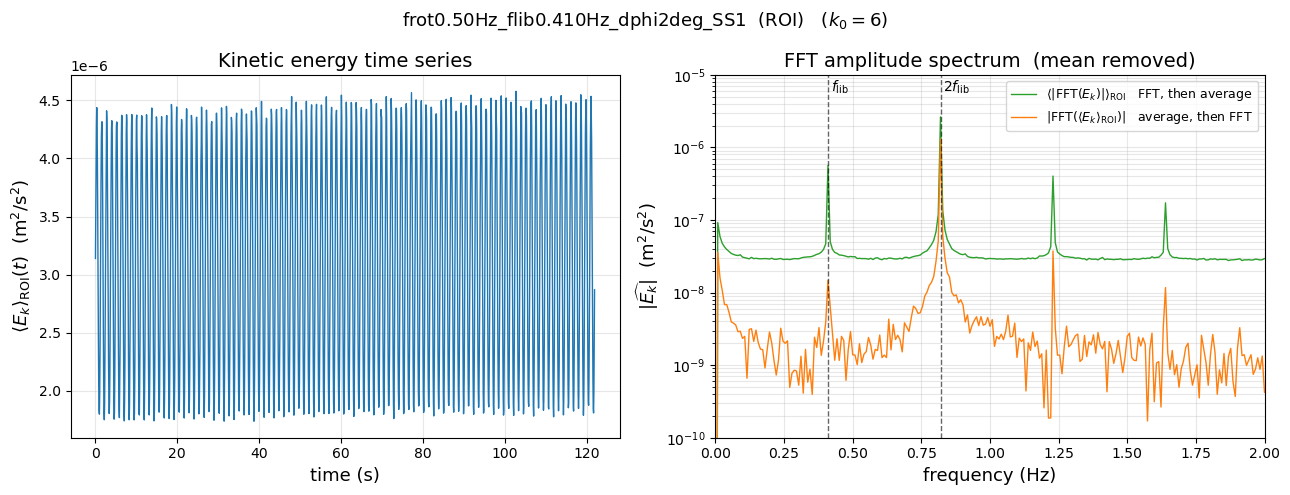

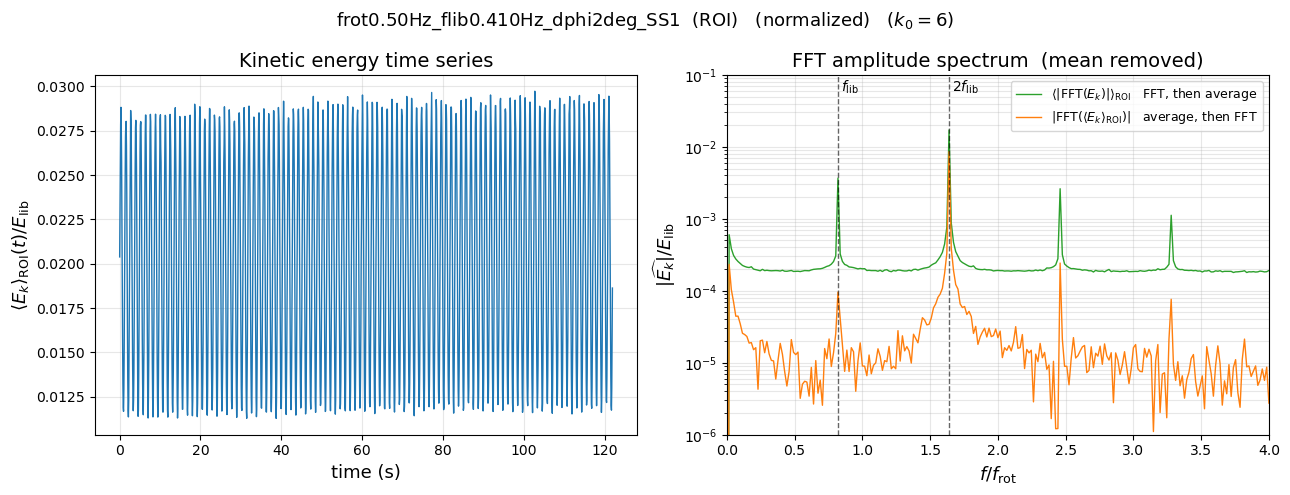

In [11]:
frot_hz, flib_hz, dphi_deg = parse_run_name(name)
flib = flib_hz if np.isfinite(flib_hz) else None

# (1) average, then FFT
freq, amp, _ = compute_fft(Ek_frame, fps, detrend=DETREND)
f_peak, amp_peak = peak_freq(freq, amp)

# (2) FFT, then average -- reuses the ROI-cropped per-point fields from cell 3.
freq_pt = amp_pt = None
f_peak_pt = amp_peak_pt = np.nan
npoints = np.nan
if PER_POINT:
    Ek_pt = 0.5 * (Ur ** 2 + Vr ** 2).reshape(-1, nframes)
    freq_pt, amp_pt, npoints = compute_fft_per_point(Ek_pt, fps, detrend=DETREND)
    f_peak_pt, amp_peak_pt = peak_freq(freq_pt, amp_pt)

# Both a raw and a normalized figure.
for _norm in (False, True):
    fig_file = os.path.join(out_dir, figure_filename('%s_%s' % (FIG_STEM, tag),
                                                     FIG_FORMAT, normalized=_norm))
    if os.path.isfile(fig_file) and not REPROCESS:
        print('[skip] %s exists and REPROCESS is False -- not overwritten'
              % os.path.basename(fig_file))
        continue
    make_fft_figure(fig_file, t, Ek_frame, freq, amp, freq_pt, amp_pt,
                    '%s  (%s)' % (name, tag), flib, frot_hz, dphi_deg, normalize=_norm)
    print('wrote', fig_file)

print('peak fft(<Ek>_ROI)  : %.4g Hz  (amp %.3e)' % (f_peak, amp_peak))
if PER_POINT:
    print('peak <fft(Ek)>_ROI  : %.4g Hz  (amp %.3e, from %s points)'
          % (f_peak_pt, amp_peak_pt, '-' if not np.isfinite(npoints) else int(npoints)))
plt.show()

## 5. Summary rows

Builds this run's row for each table with the **same columns as the batch tools**. With
`UPDATE_SUMMARY = True` the row is added/refreshed in the shared CSV+XLSX at the dataset root; with
it `False` the tables are left untouched and the rows are only displayed here.

In [12]:
fstar = flib_hz / frot_hz if frot_hz else np.nan
ss = re.search(r'SS(\d+)', name)
run_idx = int(ss.group(1)) if ss else np.nan

# Dimensionless numbers + normalised (_star) quantities for this run.
dl = dimensionless_numbers(frot_hz, flib_hz, dphi_deg)
fn = frot_hz if np.isfinite(frot_hz) and frot_hz else np.nan
ke_scale = dl['U0_mps'] ** 2 if np.isfinite(dl['U0_mps']) and dl['U0_mps'] else np.nan

ke_row = {'run': name, 'run idx': run_idx, 'processed': True,
          'frot_Hz': frot_hz, 'flib_Hz': flib_hz, 'dphi_deg': dphi_deg,
          'fstar': fstar, 'flib_star': fstar, 'calibrated': ok,
          'dt_vel_s': dt_vel, 'fps_Hz': fps, 'nframes': nframes,
          'mean_Ekin': mean_Ekin, 'std_Ekin': std_Ekin,
          'mean_Ekin_star': mean_Ekin / ke_scale,
          'std_Ekin_star': std_Ekin / ke_scale,
          'top_topo': TOP_TOPO, 'bottom_topo': BOTTOM_TOPO, 'npz': ke_npz}
ke_row.update(dl)

fft_row = {'run': name, 'run idx': run_idx, 'processed': True,
           'frot_Hz': frot_hz, 'flib_Hz': flib_hz, 'dphi_deg': dphi_deg,
           'fstar': fstar, 'flib_star': fstar, 'fps_Hz': fps,
           'nframes': nframes,
           'f_peak_Hz': f_peak, 'f_peak_star': f_peak / fn,
           'amp_peak': amp_peak, 'amp_peak_star': amp_peak / ke_scale,
           'f_peak_perPoint_Hz': f_peak_pt, 'f_peak_perPoint_star': f_peak_pt / fn,
           'amp_peak_perPoint': amp_peak_pt,
           'amp_peak_perPoint_star': amp_peak_pt / ke_scale,
           'npoints': npoints, 'top_topo': TOP_TOPO, 'bottom_topo': BOTTOM_TOPO,
           'figure': fig_file}
fft_row.update(dl)

base_dir = os.path.dirname(RUN_DIR.rstrip('/'))     # dataset root, where summaries live
ke_summary_csv  = os.path.join(base_dir, '%s_%s.csv' % (KE_SUMMARY, tag))
fft_summary_csv = os.path.join(base_dir, '%s_%s.csv' % (FFT_SUMMARY, tag))

if UPDATE_SUMMARY:
    update_summary(ke_summary_csv, ke_row)
    update_summary(fft_summary_csv, fft_row)
    print('updated %s summaries in %s' % (tag, base_dir))
    print('  ', os.path.basename(ke_summary_csv))
    print('  ', os.path.basename(fft_summary_csv))
else:
    print('UPDATE_SUMMARY is False -- summary tables left untouched.')

print()
print('KineticEnergy row :')
for k, v in ke_row.items():
    print('   %-12s %s' % (k, v))
print('KineticEnergyFFT row :')
for k, v in fft_row.items():
    print('   %-20s %s' % (k, v))

updated ROI summaries in /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly
   KineticEnergy_summary_ROI.csv
   KineticEnergyFFT_summary_ROI.csv

KineticEnergy row :
   run          frot0.50Hz_flib0.410Hz_dphi2deg_SS1
   run idx      1
   processed    True
   frot_Hz      0.5
   flib_Hz      0.41
   dphi_deg     2.0
   fstar        0.82
   flib_star    0.82
   calibrated   True
   dt_vel_s     0.04
   fps_Hz       12.5
   nframes      1525
   mean_Ekin    3.1239735159157953e-06
   std_Ekin     9.344068018258803e-07
   mean_Ekin_star 0.0202864938635339
   std_Ekin_star 0.006067861252571515
   npz          /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/frot0.50Hz_flib0.410Hz_dphi2deg_SS1/PostProcessing/KineticEnergy_timeSeries_ROI.npz
   U0_mps       0.01240938260030302
   E            1.2732395447351626e-06
   E_l          0.00015043000292239636
   delta_nu_m  